# Laboratorio Semana 8
###juan Esteban Huertas, Martin Novoa, Daniel Peñaloza


## 1) Descripción del problema

Una tienda de tecnología tiene la necesidad de organizar y gestionar su inventario de computadores de forma eficiente. Dado que cada computador está identificado por un código único, el sistema requiere una manera óptima de almacenar, buscar y manipular estos registros. Para solucionar esto, se plantea el uso de estructuras de datos tipo árbol, específicamente un Árbol Binario de Búsqueda (BST). El problema consiste en implementar y analizar un sistema jerárquico que organiza la información colocando los códigos de menor valor a la izquierda y los de mayor valor a la derecha. El sistema a desarrollar debe resolver las siguientes necesidades operativas del inventario:<br>
- Construcción e inserción: Se debe permitir la creación del inventario inicial insertando un conjunto de códigos dados (por ejemplo: 50, 30, 70, etc.) y permitir la adición de nuevos equipos posteriormente.
- Consulta: El sistema debe ser capaz de buscar códigos específicos de computadores (como 60, 25 o 80) para verificar rápidamente si se encuentran en la tienda.
- Desbalanceo: Es necesario evaluar casos críticos donde el sistema pierde eficiencia, como cuando se ingresan códigos de manera secuencial (por ejemplo: 10, 20, 30, 40 y 50), lo que provoca que la estructura se deforme y se desbalancee.
- Propuesta de optimización: Finalmente, el problema exige plantear una solución a los desbalanceos mediante el uso de un árbol AVL, el cual utiliza rotaciones para mantener las alturas de sus subárboles equilibradas y garantizar así búsquedas siempre rápidas y eficientes.



## 2) Requerimientos


## **Requerimientos Funcionales**
-RF1 **Gestión de inventario:** El sistema debe permitir organizar un inventario de computadores utilizando códigos únicos.

-RF2 **Inserción de datos:** El sistema debe permitir al usuario insertar datos (códigos) en un árbol binario de búsqueda (BST).

-RF3 **Organización lógica:** El sistema debe organizar los valores insertados de forma que los menores queden a la izquierda y los mayores a la derecha.

-RF4 **Búsqueda de elementos:** El sistema debe permitir la búsqueda de códigos específicos dentro del inventario para verificar si existen

-RF5 **Recorridos del árbol:** El sistema debe ser capaz de aplicar e imprimir los recorridos del árbol. Esto incluye el recorrido en preorden (raíz, izquierda, derecha) , inorden (izquierda, raíz, derecha) , y postorden (izquierda, derecha, raíz).

-RF6 **Actualización del árbol:** El sistema debe permitir la inserción de nuevos computadores en un árbol que ya ha sido construido previamente.

-RF7 **Análisis de desbalanceo:** El sistema debe permitir insertar secuencias de datos, como elementos ya ordenados, para reconocer y analizar cuándo un árbol se desbalancea.

-RF8 **Simulación AVL:** El sistema debe simular la inserción de datos en un árbol AVL, el cual mantiene equilibradas las alturas de sus subárboles. Para esto, el sistema debe indicar la rotación necesaria tras la inserción de elementos.

## **Requerimientos no funcionales**

-RFN1 **Usabilidad y tolerancia a fallos:** El sistema debe validar las entradas del usuario para evitar interrupciones o caídas (crashes). Si el usuario ingresa texto en lugar de números, el sistema debe capturar la excepción (ValueError) y solicitamos el formato correcto.

-RFN2 **Interfaz de Usuario (UI):** La aplicación debe operar a través de una Interfaz de Línea de Comandos (CLI). Debe proporcionar un menú de navegación claro con opciones numéricas (0 al 6) para acceder a cada una de las actividades.

-RFN3 **Representación visual:** El sistema debe imprimir una representación visual del árbol en la consola (girado 90 grados a la izquierda) utilizando niveles de indentación, para que el usuario pueda comprender la jerarquía de los nodos

-RFN4 **Manejo de estado:** El programa debe mantener el estado del árbol principal en memoria (variable arbol_principal) mientras el programa esté en ejecución. Esto garantiza que las actividades de búsqueda, recorridos y nuevas inserciones se realicen sobre los datos ingresados en la Actividad 1.

-RFN5 **Validación de tipos de datos:** El sistema debe omitir con una advertencia cualquier elemento que no sea numérico (int o float) durante la lógica de inserción interna de los nodos.

## 3) Historias de usuario **[4 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.

## Historia de usuario

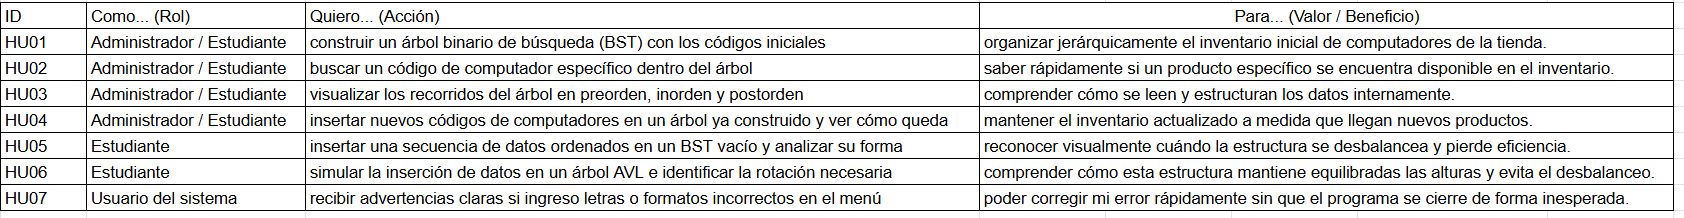



## 4) Diagramas de flujo **[5 pts]**
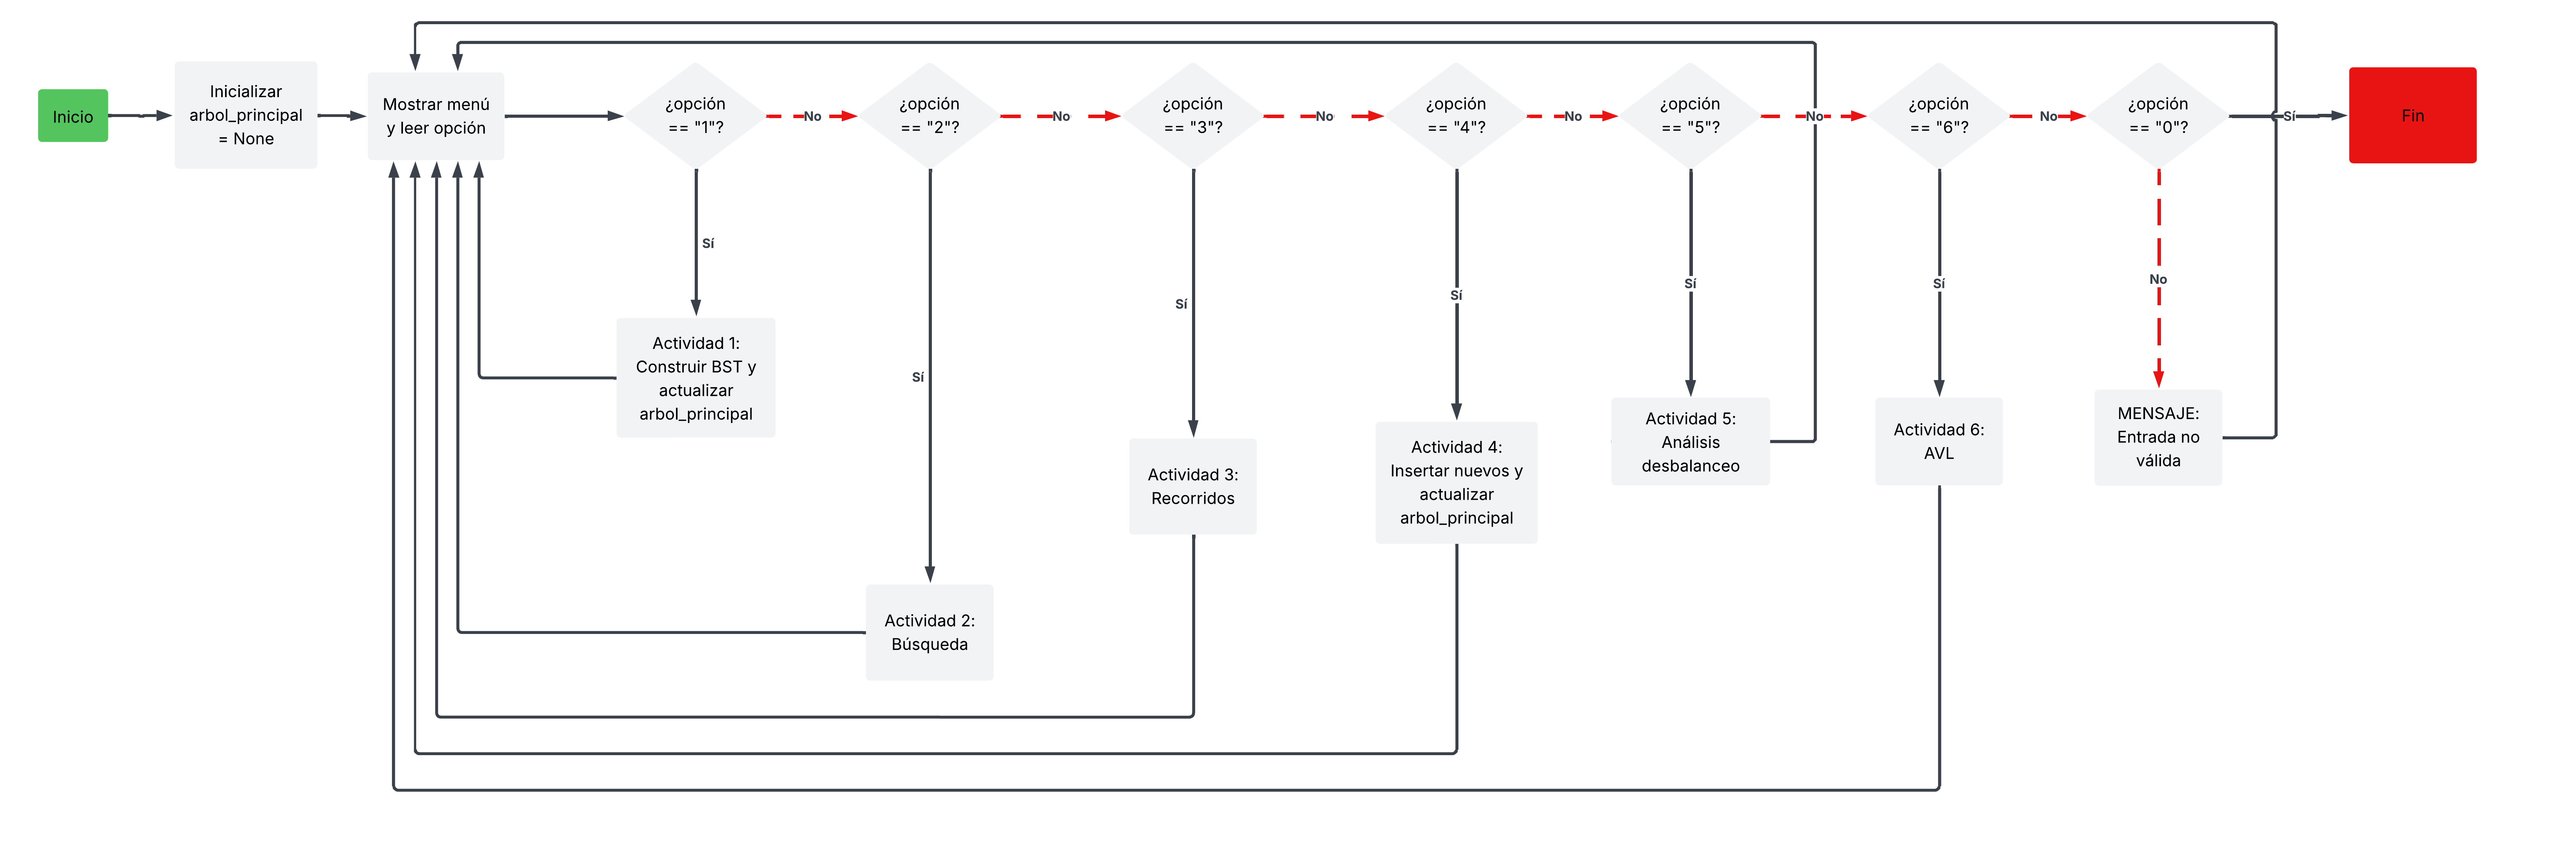


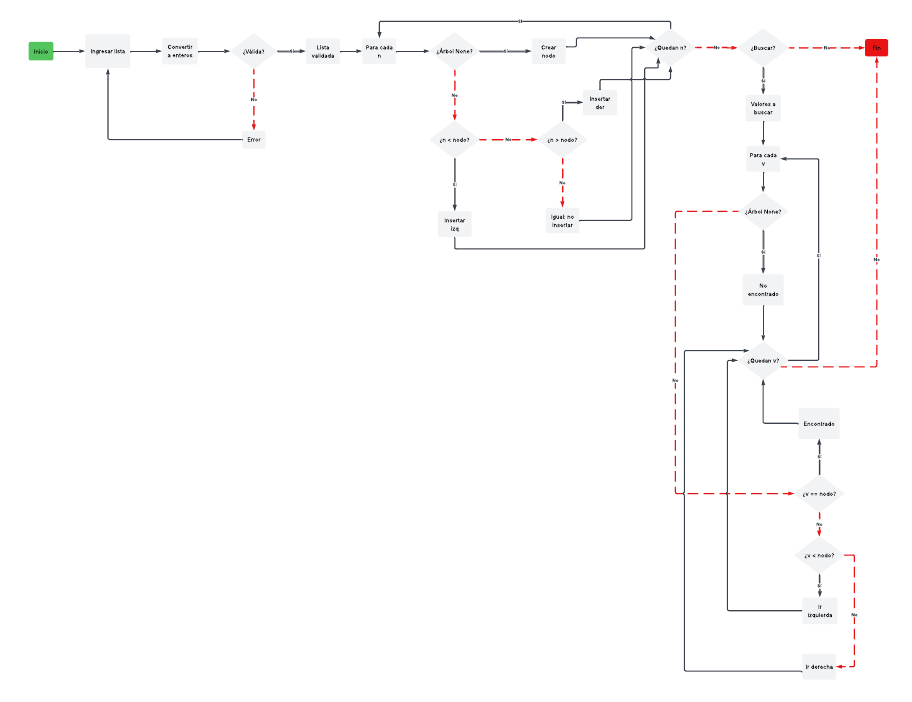





## 5) Diagramas de secuencia **[5 pts]**
Incluye un diagrama de secuencia.

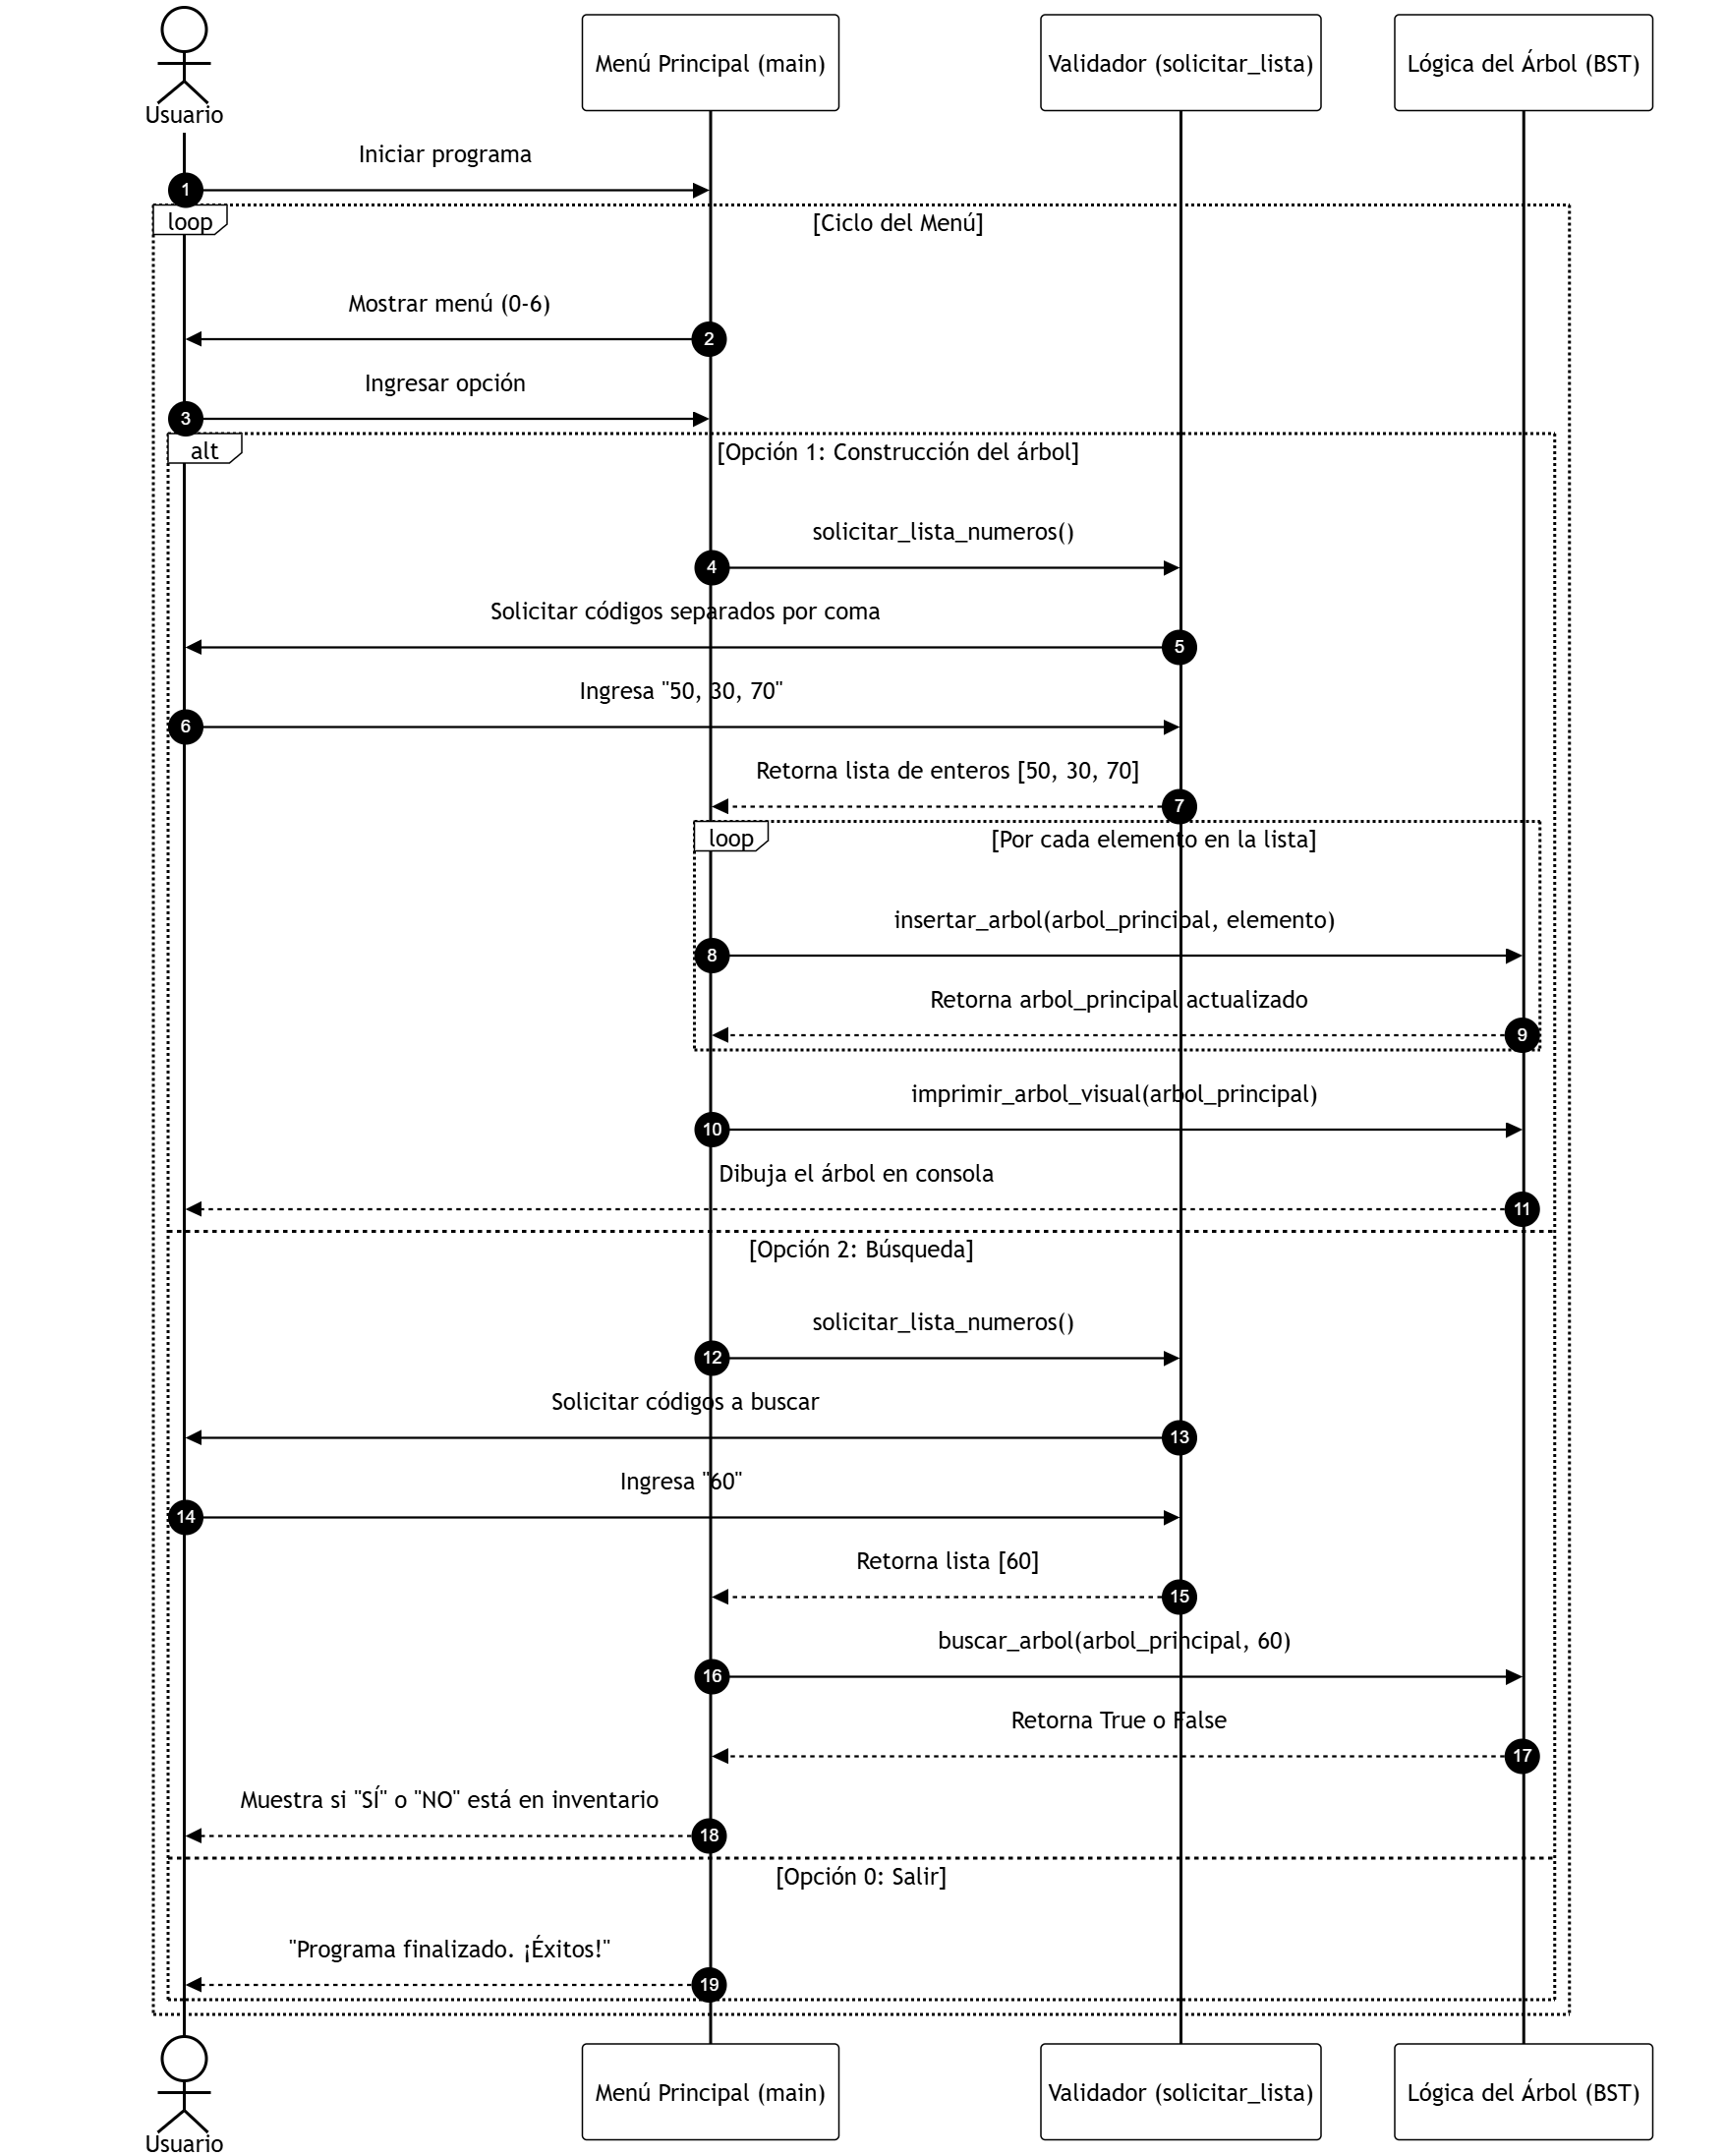

## 6) Diagramas de casos de uso **[5 pts]**
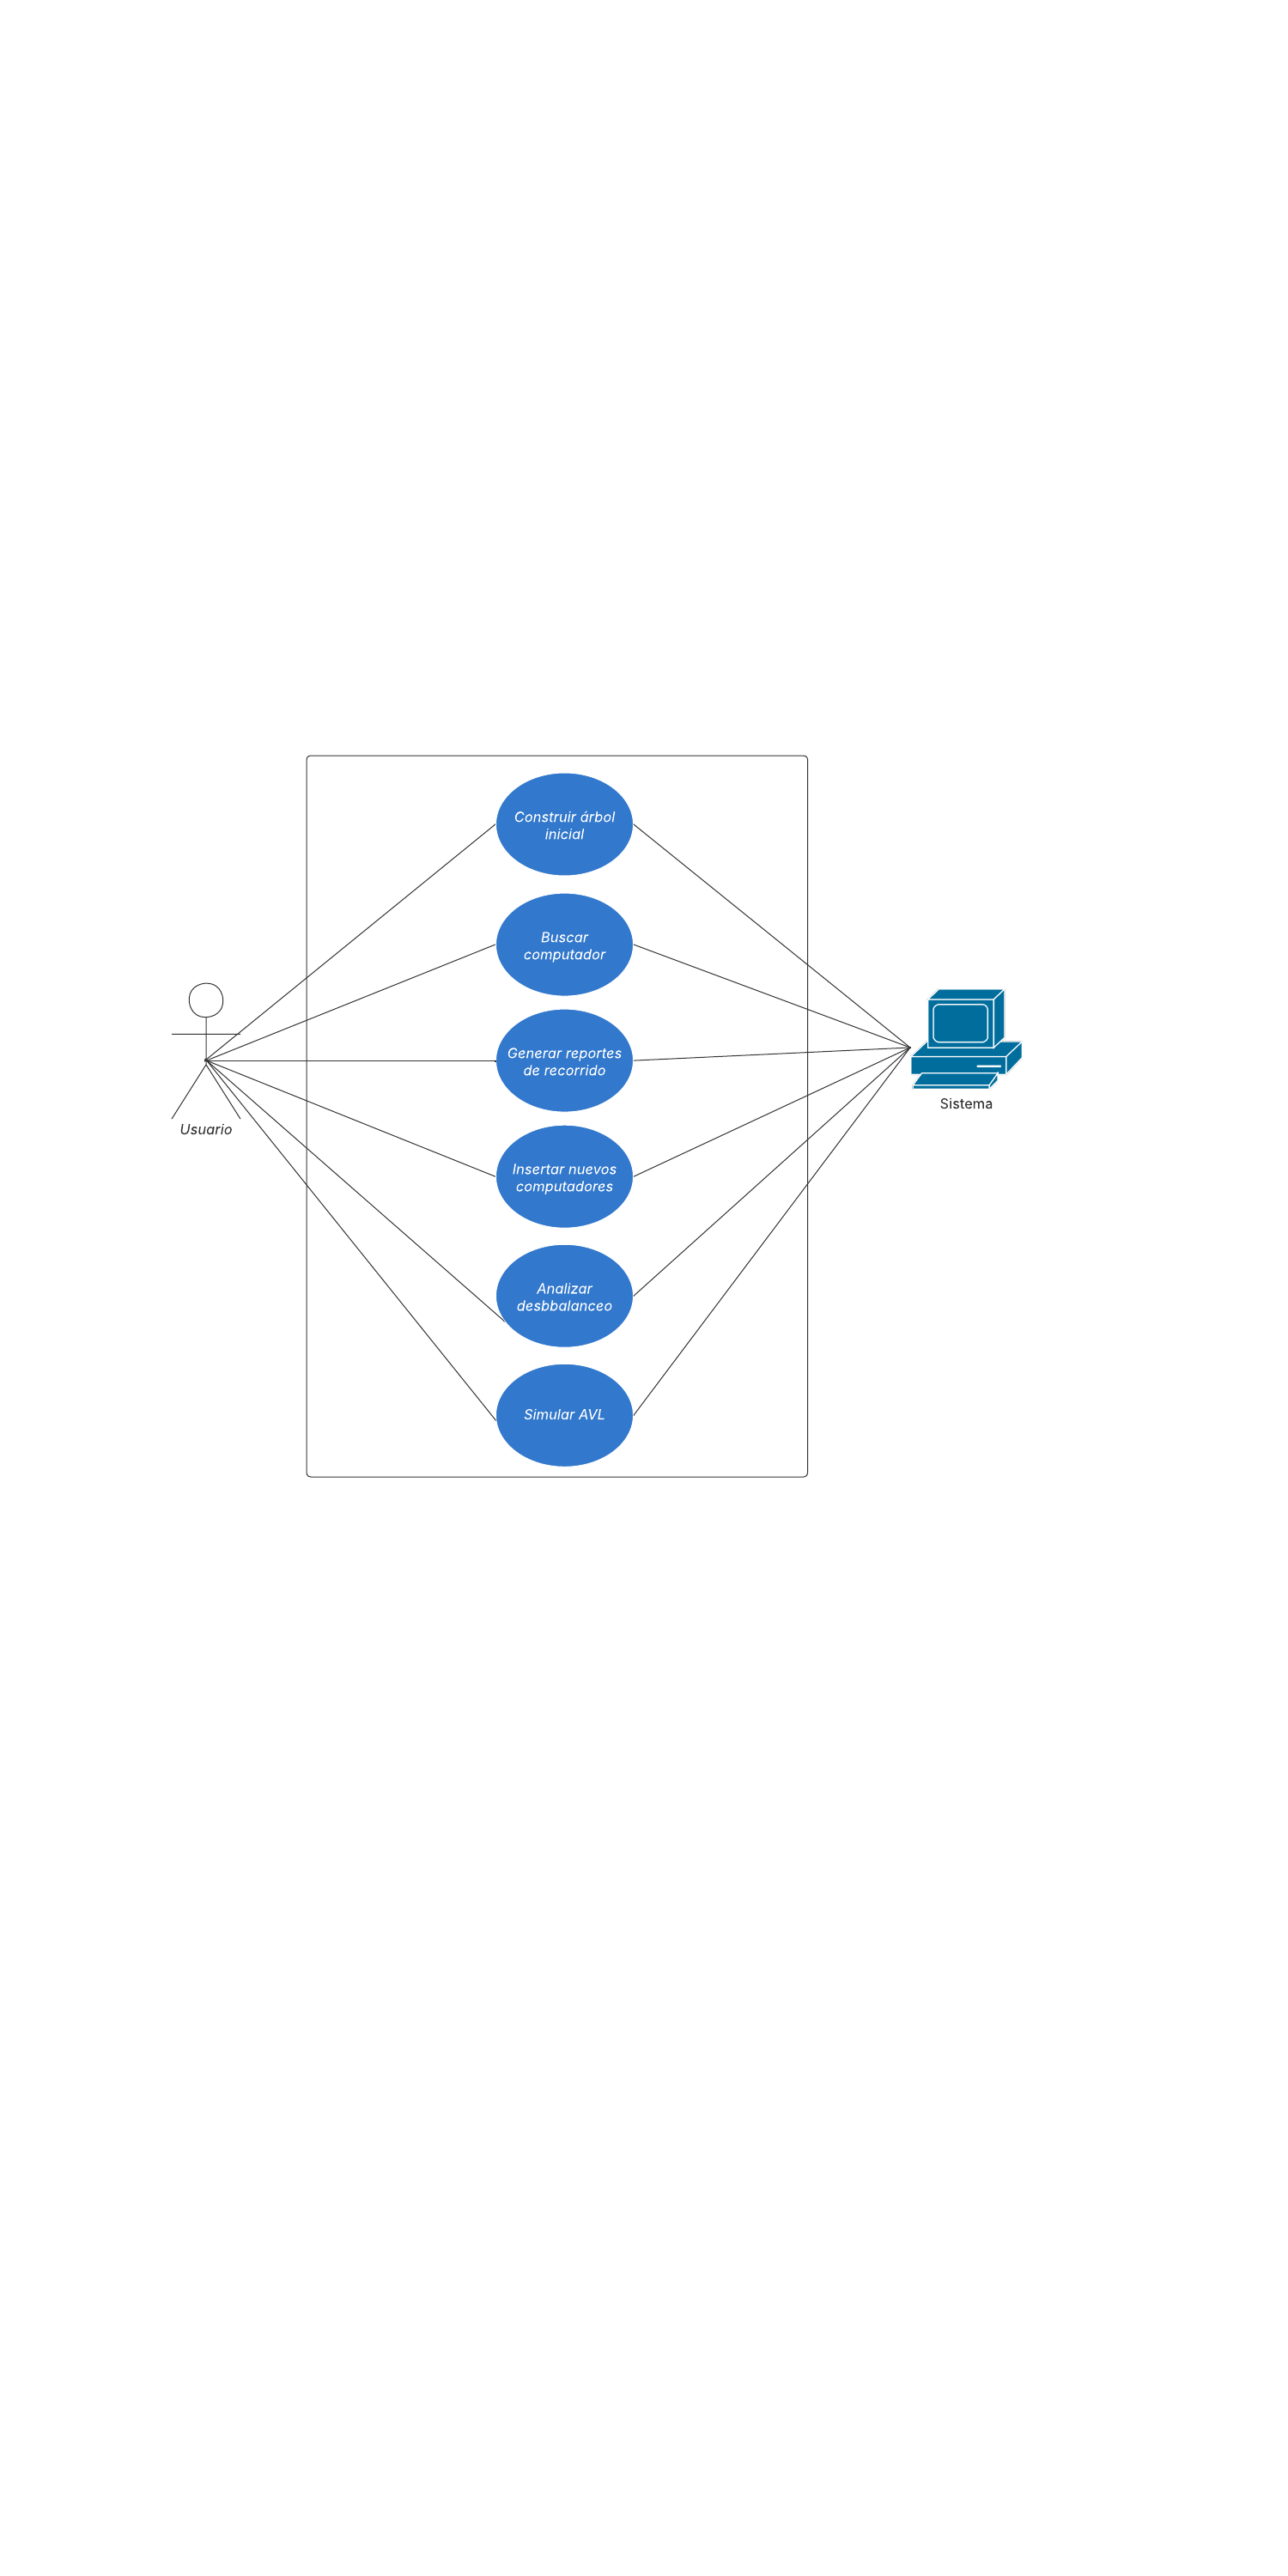

## 7) Análisis de complejidad – Optimización con programación dinámica **[5 pts]**
Incluye:
- Justificación del uso de memoización.
- Función T[n]
- Mejor y peor caso

## Respuesta
- Mejor caso: O(1) Si el elemento que se está buscando resulta ser el primer nodo (la raíz), el algoritmo lo encuentra y finaliza.
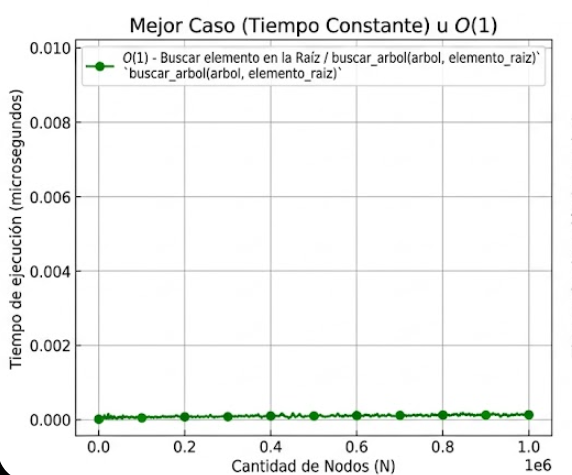
- Peor caso: O(n) Si se ingresan datos ya ordenados el árbol pierde su forma de ramificación y se convierte en una simple línea recta.
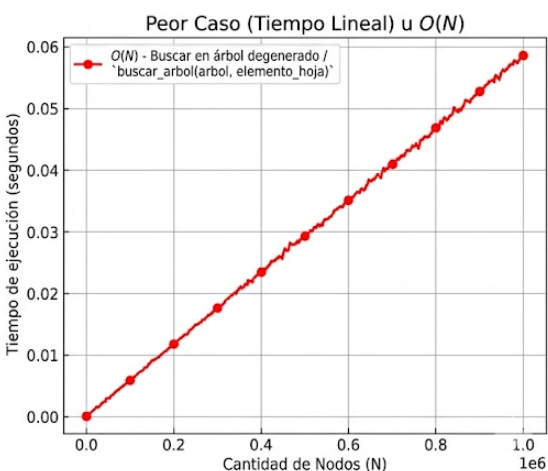




## 8) Tests **[5 pts]**
- Test 1 - Inserción

 Entrada:
 Inserción de múltiples elementos

 Salida esperada:
 Los elementos se organizan respetando la propiedad del BST

- Test 2 - Búsqueda existente

 Entrada:
Búsqueda de un elemento presente

 Salida esperada:
Elemento encontrado

- Test 3 - Búsqueda inexistente

 Entrada:
Búsqueda de un elemento no presente

 Salida esperada:
Elemento no encontrado



## 9) Código funcional **[15 pts]**



In [ ]:
# Escribe tu código aquí.
# Debe incluir: validación, función memoizada, y ejecución.
# Laboratorio: Estructuras de Datos Tipo Árbol

def solicitar_lista_numeros(mensaje):
    """Función auxiliar: Pide al usuario una lista de números y evita que el programa falle si ingresa letras."""
    while True:
        entrada = input(mensaje)
        try:
            # Separa el texto por comas, limpia espacios y lo convierte a números enteros
            partes = entrada.split(',')
            numeros = [int(p.strip()) for p in partes if p.strip()]
            if numeros:
                return numeros
            else:
                print("ERROR: Debes ingresar al menos un número.")
        except ValueError:
            # Si el usuario ingresa una letra, se captura el error sin detener el programa
            print("ERROR: Por favor, ingresa solo números separados por comas (ejemplo: 50, 30, 70).")

def insertar_arbol(arbol, elemento):
    # Validamos que sea un número por seguridad
    if not isinstance(elemento, (int, float)):
        print(f"Advertencia: El elemento '{elemento}' no es válido y será omitido.")
        return arbol

    # Restricción: Un árbol binario puede tener máximo dos hijos
    if arbol is None:
        return [elemento, None, None]

    # Restricción BST: Los menores a la izquierda y los mayores a la derecha
    if elemento < arbol[0]:
        arbol[1] = insertar_arbol(arbol[1], elemento)
    elif elemento > arbol[0]:
        arbol[2] = insertar_arbol(arbol[2], elemento)
    return arbol

def imprimir_arbol_visual(arbol, nivel=0):
    """Dibuja el árbol en consola girado"""
    if arbol is not None:
        imprimir_arbol_visual(arbol[2], nivel + 1)
        print('    ' * nivel + '-> ' + str(arbol[0]))
        imprimir_arbol_visual(arbol[1], nivel + 1)

def buscar_arbol(arbol, elemento):
    if arbol is None:
        return False
    if elemento == arbol[0]:
        return True
    if elemento < arbol[0]:
        return buscar_arbol(arbol[1], elemento)
    else:
        return buscar_arbol(arbol[2], elemento)

def inorden(arbol):
    if arbol is not None:
        inorden(arbol[1])
        print(arbol[0], end=" ")
        inorden(arbol[2])

def preorden(arbol):
    if arbol is not None:
        print(arbol[0], end=" ")
        preorden(arbol[1])
        preorden(arbol[2])

def postorden(arbol):
    if arbol is not None:
        postorden(arbol[1])
        postorden(arbol[2])
        print(arbol[0], end=" ")

# --- ACTIVIDADES ---

def actividad1(arbol_actual):
    print("\n--- Actividad 1: Construcción del árbol BST ---")
    print("Guía del laboratorio: Se sugieren los códigos 50, 30, 70, 20, 40, 60, 80.")

    elementos = solicitar_lista_numeros("Ingresa los códigos de los computadores separados por coma: ")

    # Insertar los números ingresados por el usuario
    for elemento in elementos:
        arbol_actual = insertar_arbol(arbol_actual, elemento)

    print("\nRepresentación visual del árbol:")
    imprimir_arbol_visual(arbol_actual)
    return arbol_actual  # Retornamos el árbol para guardarlo

def actividad2(arbol_actual):
    if arbol_actual is None:
        print("El árbol está vacío. Por favor, realiza la Actividad 1 primero.")
        return

    print("\n--- Actividad 2: Búsqueda ---")
    print("Guía del laboratorio: Se sugiere buscar 60, 25 y 80[cite: 39, 40, 41].")

    elementos = solicitar_lista_numeros("Ingresa los códigos que deseas buscar, separados por coma: ")

    for elemento in elementos:
        encontrado = buscar_arbol(arbol_actual, elemento)
        resultado = "SÍ está en el inventario" if encontrado else "NO está en el inventario"
        print(f"Buscar {elemento}: {resultado}")

def actividad3(arbol_actual):
    if arbol_actual is None:
        print("El árbol está vacío. Por favor, realiza la Actividad 1 primero.")
        return

    print("\n--- Actividad 3: Recorridos ---")
    print("Preorden (raíz, izquierda, derecha):")
    preorden(arbol_actual)

    print("\n\nInorden (izquierda, raíz, derecha):")
    inorden(arbol_actual)

    print("\n\nPostorden (izquierda, derecha, raíz):")
    postorden(arbol_actual)
    print("\n")

def actividad4(arbol_actual):
    if arbol_actual is None:
        print("El árbol está vacío. Por favor, realiza la Actividad 1 primero.")
        return arbol_actual

    print("\n--- Actividad 4: Inserción de nuevos computadores ---")
    print("Guía del laboratorio: Se sugiere insertar 25, 65 y 90.")

    nuevos = solicitar_lista_numeros("Ingresa los nuevos códigos a insertar, separados por coma: ")

    for elemento in nuevos:
        arbol_actual = insertar_arbol(arbol_actual, elemento)
        print(f"\nÁrbol después de insertar el código {elemento}:")
        imprimir_arbol_visual(arbol_actual)
        print("-" * 30)

    return arbol_actual

def actividad5():
    arbol_temporal = None
    print("\n--- Actividad 5: Análisis de desbalanceo ---")
    print("Guía del laboratorio: Se sugiere insertar 10, 20, 30, 40 y 50 en un árbol vacío.")

    elementos = solicitar_lista_numeros("Ingresa una secuencia de números separados por coma: ")

    for elemento in elementos:
        arbol_temporal = insertar_arbol(arbol_temporal, elemento)

    print("\nForma del árbol resultante:")
    imprimir_arbol_visual(arbol_temporal)

    print("\nAnálisis: Si ingresaste números ya ordenados de menor a mayor en un BST vacío,")
    print("todos los elementos son mayores que la raíz y se insertan a la derecha.")
    print("El árbol queda desbalanceado hacia la derecha, perdiendo eficiencia.")

def actividad6():
    print("\n--- Actividad 6: Uso de AVL ---")
    print("Guía del laboratorio: Se sugiere insertar 10, 20 y 30 en un árbol AVL.")

    elementos = solicitar_lista_numeros("Ingresa 3 números ordenados ascendentemente, separados por coma: ")

    if len(elementos) >= 3:
        print(f"\n1. Se inserta {elementos[0]} (Raíz).")
        print(f"2. Se inserta {elementos[1]} (Hijo derecho de {elementos[0]}).")
        print(f"3. Se inserta {elementos[2]} (Hijo derecho de {elementos[1]}).")
        print("Análisis: El árbol se desbalancea hacia la derecha.")
        print(f"Solución: Se realiza una rotación simple a la izquierda sobre el nodo {elementos[0]}.")
        print(f"Resultado: {elementos[1]} se convierte en la nueva raíz balanceando las alturas.")
    else:
        print("Debías ingresar al menos 3 números para simular la rotación.")

def menu():
    print("\n---- Menú: Inventario de Computadores ----")
    print("1. Actividad 1: Construcción del árbol BST")
    print("2. Actividad 2: Búsqueda")
    print("3. Actividad 3: Recorridos")
    print("4. Actividad 4: Inserción de nuevos computadores")
    print("5. Actividad 5: Análisis de desbalanceo")
    print("6. Actividad 6: Uso de AVL")
    print("0. Salir")

def main():
    opcion = ""
    # Creamos la variable principal que almacenará el árbol para que las actividades compartan los datos
    arbol_principal = None

    while opcion != "0":
        menu()
        opcion = input("\nIngrese una opción: ").strip()

        if opcion == "1":
            arbol_principal = actividad1(arbol_principal)
        elif opcion == "2":
            actividad2(arbol_principal)
        elif opcion == "3":
            actividad3(arbol_principal)
        elif opcion == "4":
            arbol_principal = actividad4(arbol_principal)
        elif opcion == "5":
            actividad5()
        elif opcion == "6":
            actividad6()
        elif opcion == "0":
            print("\nPrograma finalizado.")
        else:
            print("\n" + "="*50)
            print("ERROR: Entrada no válida.")
            print(f"Ingresaste: '{opcion}'. Por favor, escribe solo un número del 0 al 6.")
            print("="*50)

if __name__ == "__main__":
    main()

### Test aplicados

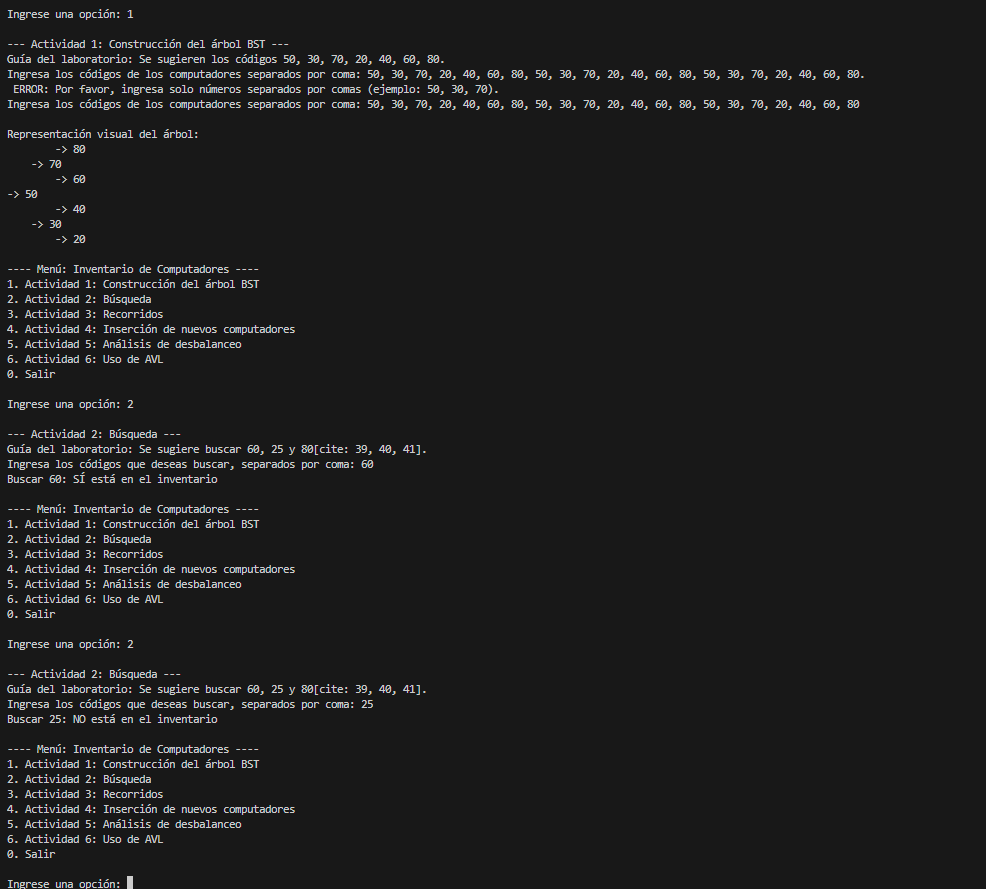